# Renewable Energy Shortfall Analysis for Germany (2012–2020)

This notebook combines:

- **Germany electricity data** from Open Power System Data (OPSD)
- **Weather data** from NASA POWER for five German cities

The goal is to create a unified dataset for analyzing and forecasting renewable energy shortfalls.

## Variables Used

### Energy Variables
- **load_mw**: Germany electricity load in MW
- **wind_generation_mw**: Germany wind generation in MW
- **solar_generation_mw**: Germany solar generation in MW
- **shortfall_mw**: Difference between load and renewable generation

### Weather Variables
- **irradiance_wm2**: Average solar irradiance across selected German cities
- **wind_speed_10m_ms**: Average wind speed at 10 m
- **temperature_2m_c**: Average air temperature at 2 m

## Study Period
2012 to 2020

## Selected Locations for Weather Averaging
- Berlin
- Hamburg
- Munich
- Frankfurt
- Cologne

In [44]:
# Imports
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [45]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#faf6fb",
    "axes.edgecolor": "#7a4d7e",
    "axes.labelcolor": "#5c2f63",
    "axes.titlecolor": "#5c2f63",
    "xtick.color": "#5c2f63",
    "ytick.color": "#5c2f63",
    "grid.color": "#d9b3df",
    "grid.alpha": 0.4,
    "text.color": "#5c2f63",
    "axes.grid": True,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.frameon": False,
    "lines.linewidth": 2,
    "patch.edgecolor": "white"
})
from cycler import cycler

mpl.rcParams["axes.prop_cycle"] = cycler(color=[
    "#c06bb7",  # pink-purple
    "#9b59b6",  # purple
    "#d16ba5",  # rosy pink
    "#7b68ee",  # soft violet
    "#e08adf"   # light orchid
])

### 1. Download Germany Energy Data from OPSD

This section loads hourly electricity load, wind generation, and solar generation data for Germany from the Open Power System Data platform.

In [46]:
opsd_url = "https://data.open-power-system-data.org/time_series/latest/time_series_60min_singleindex.csv"

opsd = pd.read_csv(
    opsd_url,
    usecols=[
        "utc_timestamp",
        "DE_load_actual_entsoe_transparency",
        "DE_wind_generation_actual",
        "DE_solar_generation_actual",
    ]
)

opsd["utc_timestamp"] = pd.to_datetime(opsd["utc_timestamp"], utc=True)

opsd = opsd[
    (opsd["utc_timestamp"] >= "2012-01-01") &
    (opsd["utc_timestamp"] < "2021-01-01")
].copy()

opsd = opsd.rename(columns={
    "DE_load_actual_entsoe_transparency": "load_mw",
    "DE_wind_generation_actual": "wind_generation_mw",
    "DE_solar_generation_actual": "solar_generation_mw"
})

opsd = opsd.dropna(subset=["load_mw", "wind_generation_mw", "solar_generation_mw"])

opsd["shortfall_mw"] = (
    opsd["load_mw"]
    - opsd["wind_generation_mw"]
    - opsd["solar_generation_mw"]
)

print("OPSD shape:", opsd.shape)
opsd.head()

OPSD shape: (50295, 5)


,utc_timestamp,load_mw,solar_generation_mw,wind_generation_mw,shortfall_mw
8,2015-01-01 07:00:00+00:00,41133.0,71.0,10208.0,30854.0
9,2015-01-01 08:00:00+00:00,42963.0,773.0,10029.0,32161.0
10,2015-01-01 09:00:00+00:00,45088.0,2117.0,10550.0,32421.0
11,2015-01-01 10:00:00+00:00,47013.0,3364.0,11390.0,32259.0
12,2015-01-01 11:00:00+00:00,48159.0,4198.0,12103.0,31858.0


### 2. Define German Cities for NASA POWER Weather Data

Since NASA POWER provides point-based weather data, several cities are selected across Germany to create a more representative national average.

In [47]:
cities = {
    "Berlin":    {"lat": 52.52, "lon": 13.405},
    "Hamburg":   {"lat": 53.5511, "lon": 9.9937},
    "Munich":    {"lat": 48.1351, "lon": 11.5820},
    "Frankfurt": {"lat": 50.1109, "lon": 8.6821},
    "Cologne":   {"lat": 50.9375, "lon": 6.9603},
}

cities

{'Berlin': {'lat': 52.52, 'lon': 13.405},
 'Hamburg': {'lat': 53.5511, 'lon': 9.9937},
 'Munich': {'lat': 48.1351, 'lon': 11.582},
 'Frankfurt': {'lat': 50.1109, 'lon': 8.6821},
 'Cologne': {'lat': 50.9375, 'lon': 6.9603}}

### 3. Create a Function to Download NASA POWER Hourly Weather Data

The function below requests hourly weather data for a given latitude and longitude in UTC format.

In [48]:
def get_nasa_power_hourly(lat, lon, start="20120101", end="20201231"):
    url = (
        "https://power.larc.nasa.gov/api/temporal/hourly/point"
        "?parameters=ALLSKY_SFC_SW_DWN,WS10M,T2M"
        "&community=RE"
        f"&longitude={lon}"
        f"&latitude={lat}"
        f"&start={start}"
        f"&end={end}"
        "&format=JSON"
        "&time-standard=UTC"
    )

    response = requests.get(url, timeout=60)
    response.raise_for_status()
    data = response.json()

    params = data["properties"]["parameter"]

    df = pd.DataFrame({
        "utc_timestamp": list(params["ALLSKY_SFC_SW_DWN"].keys()),
        "irradiance_wm2": list(params["ALLSKY_SFC_SW_DWN"].values()),
        "wind_speed_10m_ms": list(params["WS10M"].values()),
        "temperature_2m_c": list(params["T2M"].values()),
    })

    df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], format="%Y%m%d%H", utc=True)

    return df

### 4. Download NASA POWER Data for All Selected Cities

This step downloads hourly solar irradiance, wind speed, and temperature for each selected city.

In [49]:
weather_frames = []

for city, coords in cities.items():
    print(f"Downloading NASA POWER data for {city}...")
    city_df = get_nasa_power_hourly(coords["lat"], coords["lon"])
    city_df = city_df.rename(columns={
        "irradiance_wm2": f"{city}_irradiance_wm2",
        "wind_speed_10m_ms": f"{city}_wind_speed_10m_ms",
        "temperature_2m_c": f"{city}_temperature_2m_c",
    })
    weather_frames.append(city_df)

### 5. Merge Weather Data Across Cities

Each city's weather dataframe is merged using the UTC timestamp.

In [50]:
weather = weather_frames[0]

for df_city in weather_frames[1:]:
    weather = weather.merge(df_city, on="utc_timestamp", how="inner")

print("Weather shape:", weather.shape)
weather.head()

Weather shape: (78912, 16)


,utc_timestamp,Berlin_irradiance_wm2,Berlin_wind_speed_10m_ms,Berlin_temperature_2m_c,Hamburg_irradiance_wm2,Hamburg_wind_speed_10m_ms,Hamburg_temperature_2m_c,Munich_irradiance_wm2,Munich_wind_speed_10m_ms,Munich_temperature_2m_c,Frankfurt_irradiance_wm2,Frankfurt_wind_speed_10m_ms,Frankfurt_temperature_2m_c,Cologne_irradiance_wm2,Cologne_wind_speed_10m_ms,Cologne_temperature_2m_c
0,2012-01-01 00:00:00+00:00,0.0,3.24,0.25,0.0,2.86,3.79,0.0,4.03,1.21,0.0,4.20,6.12,0.0,6.01,9.12
1,2012-01-01 01:00:00+00:00,0.0,2.84,0.32,0.0,3.74,4.41,0.0,4.13,1.41,0.0,4.07,6.05,0.0,5.78,9.24
2,2012-01-01 02:00:00+00:00,0.0,2.43,0.36,0.0,4.75,5.16,0.0,4.47,1.94,0.0,4.18,6.20,0.0,5.97,9.31
3,2012-01-01 03:00:00+00:00,0.0,2.37,0.41,0.0,5.41,5.93,0.0,4.64,2.43,0.0,4.18,6.45,0.0,6.42,9.52
4,2012-01-01 04:00:00+00:00,0.0,2.65,0.88,0.0,5.72,6.65,0.0,4.80,2.73,0.0,4.26,6.65,0.0,6.87,9.77


### 6. Average the Weather Variables Across Germany

The city-based weather variables are averaged to create one representative weather series for Germany.

In [51]:
irradiance_cols = [f"{city}_irradiance_wm2" for city in cities]
wind_cols = [f"{city}_wind_speed_10m_ms" for city in cities]
temp_cols = [f"{city}_temperature_2m_c" for city in cities]

weather["irradiance_wm2"] = weather[irradiance_cols].mean(axis=1)
weather["wind_speed_10m_ms"] = weather[wind_cols].mean(axis=1)
weather["temperature_2m_c"] = weather[temp_cols].mean(axis=1)

weather_avg = weather[[
    "utc_timestamp",
    "irradiance_wm2",
    "wind_speed_10m_ms",
    "temperature_2m_c"
]].copy()

print("Averaged weather shape:", weather_avg.shape)
weather_avg.head()

Averaged weather shape: (78912, 4)


,utc_timestamp,irradiance_wm2,wind_speed_10m_ms,temperature_2m_c
0,2012-01-01 00:00:00+00:00,0.0,4.068,4.098
1,2012-01-01 01:00:00+00:00,0.0,4.112,4.286
2,2012-01-01 02:00:00+00:00,0.0,4.360,4.594
3,2012-01-01 03:00:00+00:00,0.0,4.604,4.948
4,2012-01-01 04:00:00+00:00,0.0,4.860,5.336


### 7. Merge Energy and Weather Data

This step combines the OPSD Germany energy data with the averaged NASA POWER weather data.

In [52]:
merged = opsd.merge(weather_avg, on="utc_timestamp", how="inner")

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (50295, 8)


,utc_timestamp,load_mw,solar_generation_mw,wind_generation_mw,shortfall_mw,irradiance_wm2,wind_speed_10m_ms,temperature_2m_c
0,2015-01-01 07:00:00+00:00,41133.0,71.0,10208.0,30854.0,3.652,3.858,-2.142
1,2015-01-01 08:00:00+00:00,42963.0,773.0,10029.0,32161.0,48.378,4.148,-1.322
2,2015-01-01 09:00:00+00:00,45088.0,2117.0,10550.0,32421.0,105.020,4.456,-0.006
3,2015-01-01 10:00:00+00:00,47013.0,3364.0,11390.0,32259.0,138.192,4.400,0.858
4,2015-01-01 11:00:00+00:00,48159.0,4198.0,12103.0,31858.0,154.970,4.156,1.624


### 8. Add Metadata and Units

This table summarizes the meaning and units of the variables in the final dataset.

In [53]:
units = {
    "utc_timestamp": "datetime (UTC)",
    "load_mw": "MW",
    "wind_generation_mw": "MW",
    "solar_generation_mw": "MW",
    "shortfall_mw": "MW",
    "irradiance_wm2": "W/m^2",
    "wind_speed_10m_ms": "m/s",
    "temperature_2m_c": "degC",
}

metadata_table = pd.DataFrame({
    "column": list(units.keys()),
    "unit": list(units.values()),
    "description": [
        "Timestamp",
        "Germany electricity load",
        "Germany wind generation",
        "Germany solar generation",
        "Load minus wind and solar generation",
        "Average solar irradiance across five German cities",
        "Average wind speed at 10 m across five German cities",
        "Average air temperature at 2 m across five German cities",
    ]
})

metadata_table

,column,unit,description
0,utc_timestamp,datetime (UTC),Timestamp
1,load_mw,MW,Germany electricity load
2,wind_generation_mw,MW,Germany wind generation
3,solar_generation_mw,MW,Germany solar generation
4,shortfall_mw,MW,Load minus wind and solar generation
5,irradiance_wm2,W/m^2,Average solar irradiance across five German ci...
6,wind_speed_10m_ms,m/s,Average wind speed at 10 m across five German ...
7,temperature_2m_c,degC,Average air temperature at 2 m across five Ger...


### 9. Dataset Overview

This section checks the time range, missing values, and summary statistics of the merged dataset.

In [54]:
print("Time range:")
print("Start:", merged["utc_timestamp"].min())
print("End:  ", merged["utc_timestamp"].max())

print("\nMissing values:")
print(merged.isna().sum())

print("\nSummary statistics:")
merged.describe()

Time range:
Start: 2015-01-01 07:00:00+00:00
End:   2020-09-30 23:00:00+00:00

Missing values:
utc_timestamp          0
load_mw                0
solar_generation_mw    0
wind_generation_mw     0
shortfall_mw           0
irradiance_wm2         0
wind_speed_10m_ms      0
temperature_2m_c       0
dtype: int64

Summary statistics:


,load_mw,solar_generation_mw,wind_generation_mw,shortfall_mw,irradiance_wm2,wind_speed_10m_ms,temperature_2m_c
count,50295.000000,50295.000000,50295.000000,50295.000000,50295.000000,50295.000000,50295.000000
mean,55487.982980,4566.170673,11553.928363,39367.883945,131.760759,4.002748,10.379830
std,10016.027177,6940.373607,9078.275500,12105.356056,194.429932,1.725024,8.193967
min,31307.000000,0.000000,135.000000,648.000000,0.000000,0.846000,-12.560000
25%,47100.000000,0.000000,4505.500000,31493.000000,0.000000,2.758000,3.706000
50%,55090.000000,172.000000,9016.000000,39726.000000,7.204000,3.612000,9.818000
75%,64305.000000,7342.500000,16119.000000,47796.000000,211.683000,4.854000,16.634000
max,77549.000000,32947.000000,46064.000000,73370.000000,913.620000,15.026000,35.692000


#### Time Range
The dataset spans from **January 2015 to September 2020**, providing over five years of hourly observations of electricity demand, renewable generation, and weather variables for Germany.
#### Missing Values
A missing value analysis shows that all variables contain **zero missing observations**, indicating that the merging of the OPSD energy dataset with NASA POWER weather data was successful and produced a complete dataset suitable for analysis.

### Interpretation of Summary Statistics

#### Electricity Load (MW)
* **Mean load:** ~55,488 MW
* **Minimum load:** ~31,307 MW
* **Maximum load:** ~77,549 MW
Electricity demand in Germany varies substantially over time, ranging from approximately **31 GW to 77 GW**. The average demand is about **55 GW**, indicating the typical load on the German electricity grid during the study period. The wide range reflects seasonal changes, daily demand cycles, and variations in economic activity.
#### Solar Generation (MW)
* **Mean:** ~4,566 MW
* **Median:** ~172 MW
* **Maximum:** ~32,947 MW
Solar generation exhibits a highly skewed distribution. While the maximum solar output reaches nearly **33 GW**, the median value is only **172 MW**, indicating that solar generation is zero or very low for a large portion of the dataset. This occurs because solar generation is absent during nighttime hours and varies significantly depending on daylight and weather conditions.

#### Wind Generation (MW)
* **Mean:** ~11,553 MW
* **Maximum:** ~46,064 MW
Wind generation contributes significantly to Germany’s electricity supply, with an average output of approximately **11.6 GW**. However, wind generation varies widely, reaching peaks of over **46 GW** during periods of strong wind conditions. This variability reflects the intermittent nature of wind energy.

#### Renewable Energy Shortfall (MW)
* **Mean:** ~39,368 MW
The renewable energy shortfall represents the portion of electricity demand not met by wind and solar generation. On average, the shortfall is approximately **39 GW**, indicating that renewable sources alone are typically insufficient to meet total electricity demand. This highlights the importance of other generation sources such as hydro, natural gas, and imports in maintaining grid stability.

#### Solar Irradiance (W/m²)
* **Mean:** ~131 W/m²
* **Maximum:** ~914 W/m²
Solar irradiance values range from **0 to over 900 W/m²**, reflecting the natural variation between nighttime conditions and peak sunlight hours. The average irradiance of approximately **131 W/m²** reflects the inclusion of nighttime observations where irradiance is zero.

#### Wind Speed (m/s)
* **Mean:** ~4.0 m/s
* **Maximum:** ~15 m/s
Wind speeds average around **4 m/s**, with maximum recorded speeds exceeding **15 m/s**. These variations strongly influence wind power generation since wind turbine output increases rapidly with wind speed.

#### Temperature (°C)
* **Mean:** ~10.4 °C
* **Range:** −12.6 °C to 35.7 °C
Air temperature ranges from approximately **−12.6°C to 35.7°C**, capturing both winter and summer conditions across Germany. Temperature influences electricity demand, particularly during cold periods when heating requirements increase.

Overall, the dataset captures substantial variability in both electricity demand and renewable generation, providing a suitable foundation for analyzing renewable energy shortfalls and their relationship to weather conditions.

In [55]:
print("Final merged dataset info:")
print(merged.shape)
print(merged.columns)
print("\n Data Types of Variables: \n")
merged.info()
print("Duplicated timestamps: \n")
merged["utc_timestamp"].duplicated().sum()

Final merged dataset info:
(50295, 8)
Index(['utc_timestamp', 'load_mw', 'solar_generation_mw', 'wind_generation_mw',
       'shortfall_mw', 'irradiance_wm2', 'wind_speed_10m_ms',
       'temperature_2m_c'],
      dtype='object')

 Data Types of Variables: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50295 entries, 0 to 50294
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   utc_timestamp        50295 non-null  datetime64[ns, UTC]
 1   load_mw              50295 non-null  float64            
 2   solar_generation_mw  50295 non-null  float64            
 3   wind_generation_mw   50295 non-null  float64            
 4   shortfall_mw         50295 non-null  float64            
 5   irradiance_wm2       50295 non-null  float64            
 6   wind_speed_10m_ms    50295 non-null  float64            
 7   temperature_2m_c     50295 non-null  float64            
dtypes: datet

np.int64(0)

 The merged dataset contains 50,295 hourly observations and 8 variables. The timestamp is stored in UTC datetime format, while all other variables are numeric floating-point values. Since all columns contain 50,295 non-null values, the dataset is complete and well-structured for time-series analysis.

### 10. Save the Final Dataset

The merged dataset is saved as a CSV file for later use in forecasting and visualization.

In [56]:
merged.to_csv("germany_energy_weather_2012_2020.csv", index=False)
print("Saved file: germany_energy_weather_2012_2020.csv")

Saved file: germany_energy_weather_2012_2020.csv


## Part 2: Exploratory Data Analysis

### Visualize Energy Time Series

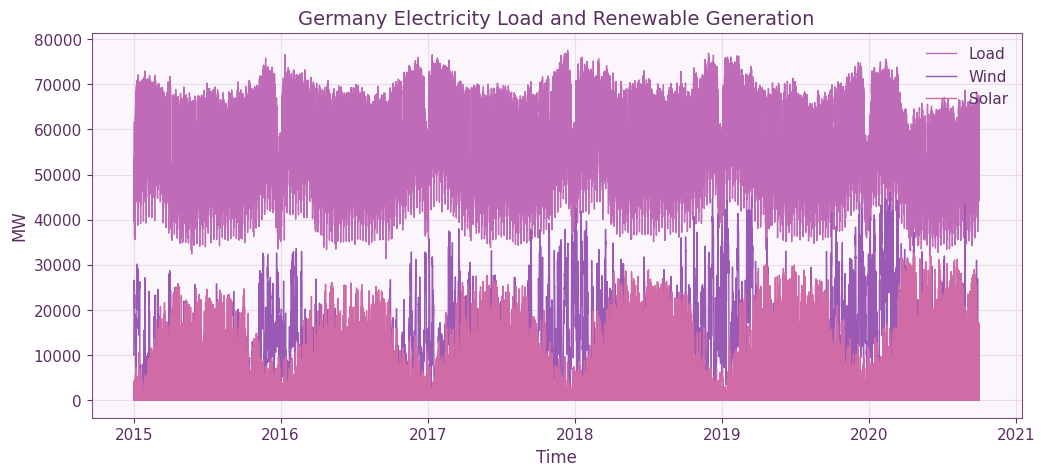

In [57]:
plt.figure(figsize=(12,5))
plt.plot(merged["utc_timestamp"], merged["load_mw"], label="Load", linewidth=1)
plt.plot(merged["utc_timestamp"], merged["wind_generation_mw"], label="Wind", linewidth=1)
plt.plot(merged["utc_timestamp"], merged["solar_generation_mw"], label="Solar", linewidth=1)

plt.legend()
plt.title("Germany Electricity Load and Renewable Generation")
plt.xlabel("Time")
plt.ylabel("MW")
plt.show()

The time-series plot shows hourly electricity demand (load) alongside wind and solar generation in Germany between 2015 and 2020. Electricity load fluctuates between approximately 30 GW and 77 GW, reflecting daily demand cycles and seasonal variations. Demand generally peaks during winter periods due to increased heating and reduced daylight hours.

Wind generation exhibits significant variability throughout the dataset. Periods of strong wind conditions produce generation peaks exceeding 40 GW, while calm periods result in substantially lower output. This variability highlights the intermittent nature of wind energy.

Solar generation displays a strong seasonal and daily cycle, with generation occurring only during daylight hours and peaking during summer months when solar irradiance is highest.

Overall, the plot demonstrates that while renewable energy contributes significantly to electricity supply, it does not consistently match total electricity demand. This mismatch between renewable generation and demand motivates the analysis of renewable energy shortfalls in the German power system.

### Distribution of Variables

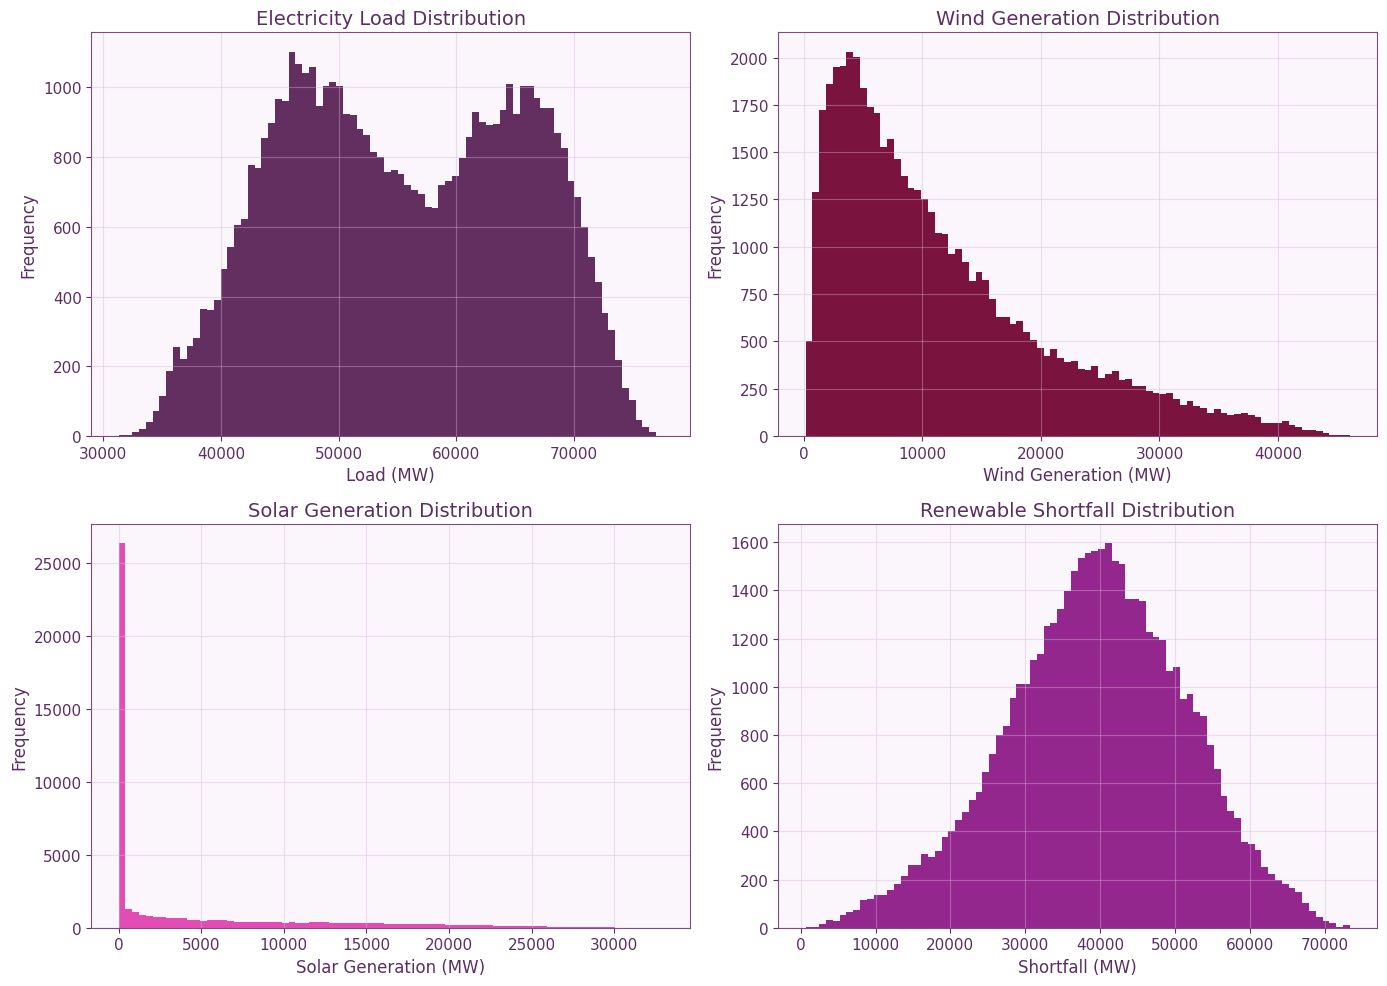

In [58]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

merged["load_mw"].hist(ax=axes[0,0], bins=80, color="#632f60")
axes[0,0].set_title("Electricity Load Distribution")
axes[0,0].set_xlabel("Load (MW)")
axes[0,0].set_ylabel("Frequency")

merged["wind_generation_mw"].hist(ax=axes[0,1], bins=80, color="#7a133e")
axes[0,1].set_title("Wind Generation Distribution")
axes[0,1].set_xlabel("Wind Generation (MW)")
axes[0,1].set_ylabel("Frequency")

merged["solar_generation_mw"].hist(ax=axes[1,0], bins=80, color="#e24cb5")
axes[1,0].set_title("Solar Generation Distribution")
axes[1,0].set_xlabel("Solar Generation (MW)")
axes[1,0].set_ylabel("Frequency")

merged["shortfall_mw"].hist(ax=axes[1,1], bins=80, color="#94278e")
axes[1,1].set_title("Renewable Shortfall Distribution")
axes[1,1].set_xlabel("Shortfall (MW)")
axes[1,1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### Plot 1
The electricity load distribution appears bimodal, indicating two dominant demand regimes. Lower demand values likely correspond to periods of reduced consumption such as nighttime or warmer months, while higher demand levels correspond to periods of increased electricity use, particularly during winter when heating demand rises.
#### Plot 2
Wind generation exhibits a positively skewed distribution, indicating that lower levels of wind generation occur more frequently while high generation events are less common but possible during periods of strong wind conditions.
#### Plot 3
Solar generation shows a large concentration of values at zero, reflecting the absence of solar generation during nighttime hours. The long tail of higher values corresponds to daylight periods with increasing solar irradiance.
#### Plot 4
The renewable shortfall distribution is approximately normally distributed, centered around 40,000 MW. This indicates that renewable generation frequently supplies only a portion of electricity demand, requiring additional generation sources to meet total system load.

### Shortfall Behaviour

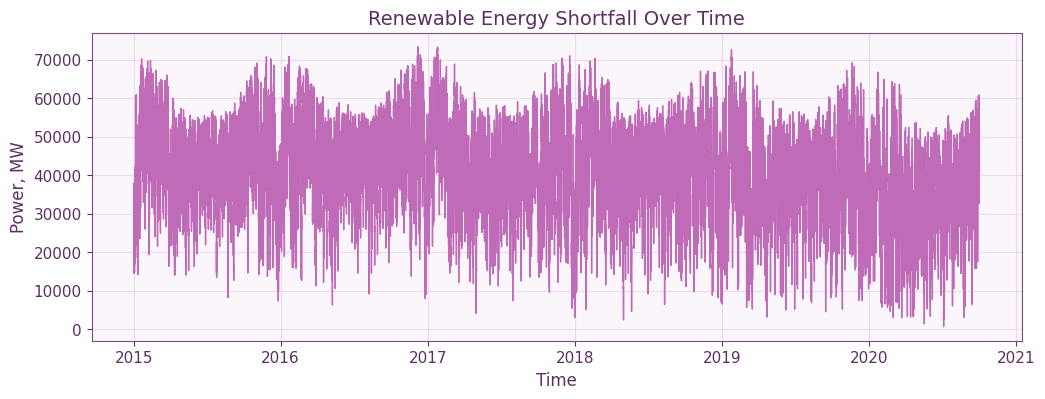

In [59]:
plt.figure(figsize=(12,4))
plt.plot(merged["utc_timestamp"], merged["shortfall_mw"], linewidth=1)
plt.title("Renewable Energy Shortfall Over Time")
plt.xlabel("Time")
plt.ylabel("Power, MW")
plt.show()

The time-series plot illustrates the renewable energy shortfall in Germany from 2015 to 2020. Renewable shortfall is defined as the difference between electricity demand and the combined generation from wind and solar power. Positive values therefore indicate the portion of electricity demand that must be supplied by other energy sources such as hydroelectric power, natural gas, coal, or imports.

The plot shows significant variability in renewable shortfalls across the study period. Most values lie between approximately 20,000 MW and 60,000 MW, with an average shortfall of roughly 39,000 MW. This indicates that wind and solar generation alone are typically insufficient to meet total electricity demand.

Seasonal patterns are also visible. Shortfalls tend to decrease during periods of high renewable generation, particularly when wind output increases or during summer months when solar generation peaks. Conversely, larger shortfalls occur when renewable generation is low relative to demand.

The high variability in the shortfall highlights the intermittent nature of renewable energy sources and underscores the importance of additional generation capacity, energy storage, or demand management strategies to ensure reliable electricity supply.

### Renewable Contribution

In [60]:
merged["renewable_share"] = (
    merged["wind_generation_mw"]
    + merged["solar_generation_mw"]
) / merged["load_mw"]

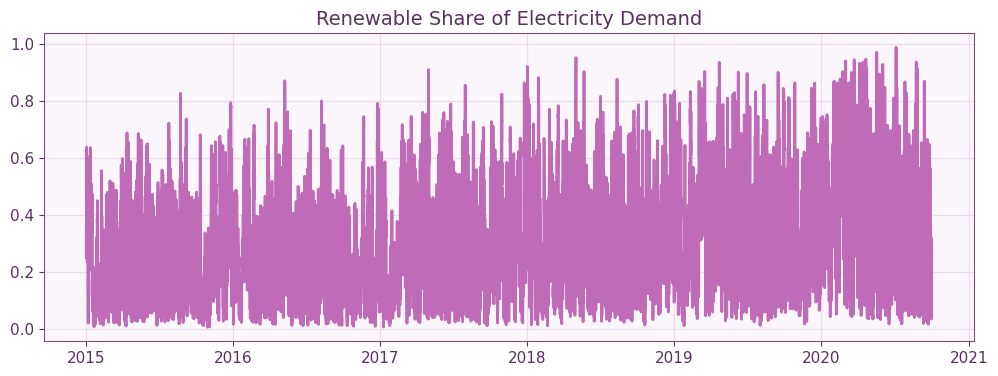

In [61]:
plt.figure(figsize=(12,4))
plt.plot(merged["utc_timestamp"], merged["renewable_share"])
plt.title("Renewable Share of Electricity Demand")
plt.show()

The plot illustrates the proportion of Germany’s electricity demand that is met by wind and solar generation between 2015 and 2020. The renewable share is calculated as the ratio of total renewable generation (wind plus solar) to total electricity load.

The figure shows substantial variability in the renewable share over time. In many hours, renewable sources contribute less than 20–30% of total electricity demand, particularly during periods of low wind conditions or nighttime when solar generation is unavailable.

However, there are also periods when renewable generation accounts for a much larger share of electricity demand. In some instances, the renewable share approaches 80–100%, indicating that wind and solar generation can occasionally meet most of the electricity demand during favorable weather conditions.

Overall, the plot demonstrates both the growing contribution of renewable energy and the variability associated with wind and solar resources. This variability contributes directly to renewable energy shortfalls and highlights the importance of complementary energy sources or storage systems to ensure reliable electricity supply.

### Weather vs Generation Relationships

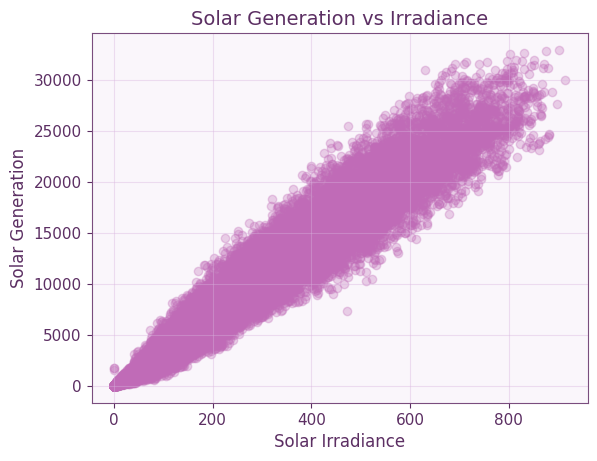

In [62]:
# Relationship between solar generation and irradiance
plt.scatter(
    merged["irradiance_wm2"],
    merged["solar_generation_mw"],
    alpha=0.3
)
plt.xlabel("Solar Irradiance")
plt.ylabel("Solar Generation")
plt.title("Solar Generation vs Irradiance")
plt.show()

The scatter plot demonstrates a strong positive relationship between solar irradiance and solar electricity generation. As irradiance increases, solar power output also increases, confirming that solar generation is strongly dependent on available sunlight. The relationship appears approximately linear across most irradiance values, indicating that solar generation increases proportionally with solar irradiance under typical operating conditions.
Although the overall relationship is strong, some variability is observed for similar irradiance levels. This spread likely results from differences in solar installation locations, panel orientation, cloud cover variability, and other environmental factors affecting solar power production. At low irradiance levels, solar generation approaches zero, reflecting nighttime conditions or periods with minimal sunlight. 


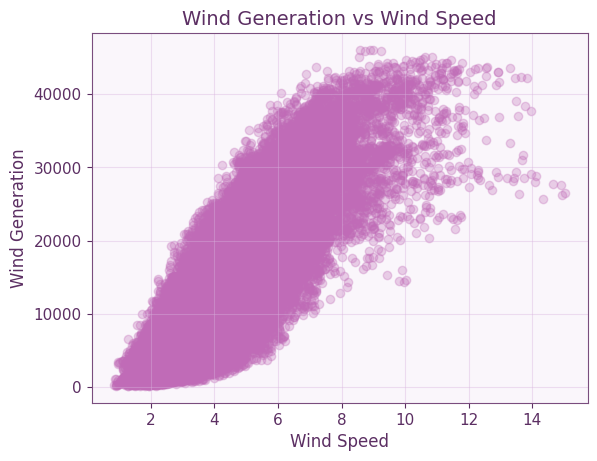

In [63]:
# Relationship between wind generation and wind speed
plt.scatter(
    merged["wind_speed_10m_ms"],
    merged["wind_generation_mw"],
    alpha=0.3
)
plt.xlabel("Wind Speed")
plt.ylabel("Wind Generation")
plt.title("Wind Generation vs Wind Speed")
plt.show()

The scatter plot illustrates the relationship between wind speed and wind electricity generation in Germany. As wind speed increases, wind generation also increases, indicating a positive relationship between the two variables. 
The relationship between wind speed and generation is non-linear, reflecting the physics of wind turbines, where power output increases roughly with the cube of wind speed. This causes generation to rise rapidly once wind speeds reach moderate levels. At higher wind speeds, wind generation begins to plateau, indicating that turbines are approaching their rated power output. This results in diminishing increases in generation despite further increases in wind speed.
A wide spread in the data is observed at similar wind speeds. This variability likely results from geographic differences in wind conditions, variations in turbine locations across Germany, and the aggregated nature of national generation data.

### Correlation Matrix

<Axes: >

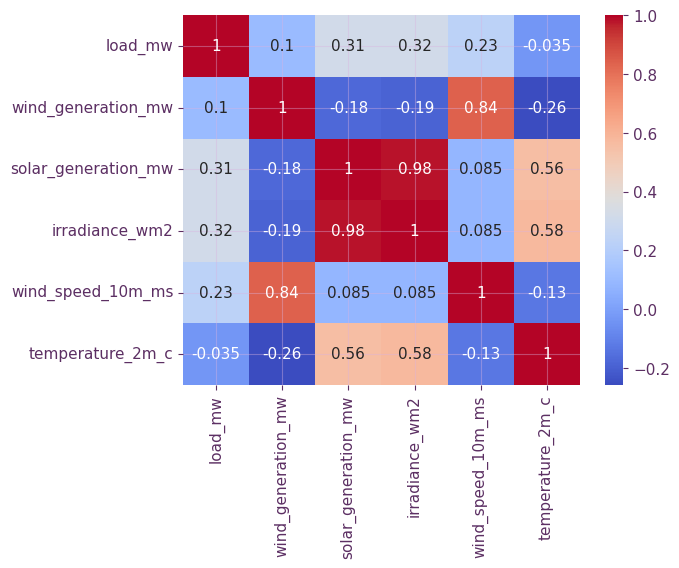

In [64]:
corr = merged[[
    "load_mw",
    "wind_generation_mw",
    "solar_generation_mw",
    "irradiance_wm2",
    "wind_speed_10m_ms",
    "temperature_2m_c"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

A correlation analysis was performed to examine the relationships between electricity demand, renewable generation, and weather variables. The results highlight several strong relationships that align with the physical drivers of renewable energy production.
Solar generation shows a very strong positive correlation with solar irradiance (r ≈ 0.98). This indicates that solar power output is almost directly proportional to the amount of incoming solar radiation. The result is consistent with the physics of photovoltaic systems, where electricity production increases with available sunlight.
Wind generation is strongly correlated with wind speed (r ≈ 0.84). Higher wind speeds generally lead to greater electricity production from wind turbines. The relationship is not perfectly linear due to turbine operating limits and the nonlinear dependence of power on wind speed.
Temperature shows a moderate positive correlation with solar irradiance (r ≈ 0.58). This relationship occurs because both variables are influenced by solar radiation and seasonal patterns, with higher temperatures typically occurring during periods of stronger sunlight.
A moderate positive correlation exists between temperature and solar generation (r ≈ 0.56). Warmer conditions generally occur during periods of higher solar irradiance, which also leads to increased solar electricity production.
Electricity load shows a moderate positive correlation with solar generation and irradiance. This may reflect daily patterns in electricity demand, where higher demand often occurs during daytime hours when solar production is also active.
Wind and solar generation exhibit a weak negative correlation. This suggests that periods of strong wind are not necessarily associated with high solar generation, reflecting the differing weather conditions that influence each renewable energy source.
A weak negative correlation is observed between wind speed and temperature, suggesting that higher wind speeds may occur more frequently during cooler atmospheric conditions.
Electricity load shows little correlation with temperature in the dataset. This may occur because Germany's electricity demand is influenced by multiple factors, including industrial activity, seasonal behavior, and heating demand.

### Seasonal Patterns

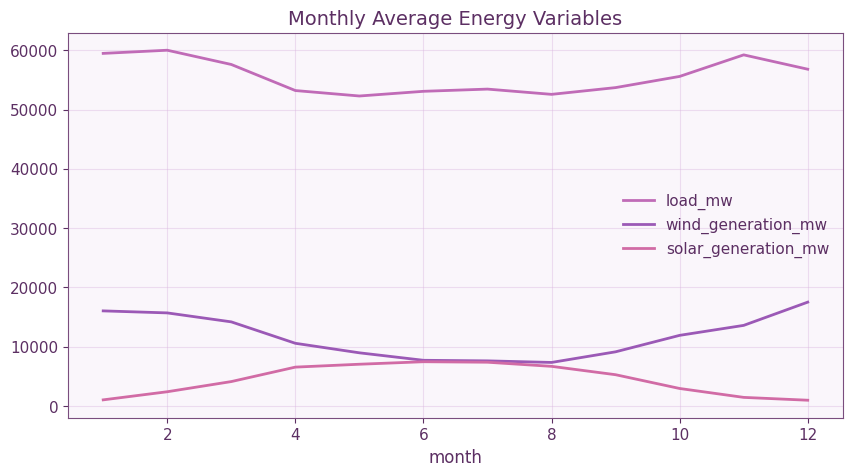

In [65]:
merged["month"] = merged["utc_timestamp"].dt.month

monthly = merged.groupby("month")[[
    "load_mw",
    "wind_generation_mw",
    "solar_generation_mw"
]].mean()

monthly.plot(figsize=(10,5))
plt.title("Monthly Average Energy Variables")
plt.show()

The figure shows the monthly average electricity load, wind generation, and solar generation in Germany. The plot highlights clear seasonal patterns in both electricity demand and renewable energy production.
Electricity demand is highest during the winter months, reaching approximately 59–60 GW in January and December. Demand decreases during spring and early summer, reaching a minimum of around 52–53 GW. This seasonal pattern likely reflects increased heating demand and lower daylight hours during winter periods.
Wind generation follows an opposite seasonal pattern to solar power. Wind output is highest during the winter months, when atmospheric conditions produce stronger and more frequent wind events. Wind generation decreases during the summer, reaching its lowest levels around May to August.
This seasonal complementarity between wind and solar generation helps stabilize renewable energy supply over the year, partially offsetting the variability of individual renewable sources. However, total renewable output still varies significantly throughout the year. During periods of low renewable generation relative to demand, electricity shortfalls must be met by other generation sources such as fossil fuels, imports, or energy storage systems.

### Extreme Events

In [66]:
merged.nlargest(10, "shortfall_mw")

,utc_timestamp,load_mw,solar_generation_mw,wind_generation_mw,shortfall_mw,irradiance_wm2,wind_speed_10m_ms,temperature_2m_c,renewable_share,month
16855,2016-12-06 16:00:00+00:00,75176.0,0.0,1806.0,73370.0,0.000,1.810,-0.464,0.024024,12
18007,2017-01-24 16:00:00+00:00,74786.0,9.0,1477.0,73300.0,0.000,1.962,-4.146,0.019870,1
18008,2017-01-24 17:00:00+00:00,74506.0,0.0,1525.0,72981.0,0.000,2.022,-4.594,0.020468,1
18001,2017-01-24 10:00:00+00:00,75845.0,2001.0,953.0,72891.0,76.982,2.020,-2.382,0.038948,1
18000,2017-01-24 09:00:00+00:00,75098.0,1435.0,798.0,72865.0,61.164,2.086,-3.342,0.029734,1
17998,2017-01-24 07:00:00+00:00,73687.0,157.0,671.0,72859.0,8.168,1.732,-5.386,0.011237,1
17984,2017-01-23 17:00:00+00:00,74620.0,0.0,1902.0,72718.0,0.000,1.836,-4.840,0.025489,1
35527,2019-01-24 16:00:00+00:00,74057.0,2.0,1400.0,72655.0,0.000,1.634,-4.442,0.018931,1
35528,2019-01-24 17:00:00+00:00,74138.0,0.0,1503.0,72635.0,0.000,1.702,-4.800,0.020273,1
17999,2017-01-24 08:00:00+00:00,73960.0,724.0,719.0,72517.0,33.072,1.960,-4.388,0.019511,1


The most severe renewable shortfall events are concentrated in the winter months, particularly January and December. This suggests that the German electricity system is most vulnerable during colder periods when electricity demand is high and solar generation is naturally limited.
Solar generation is negligible during the largest shortfall events, with many observations showing near-zero solar output. This is consistent with winter and late-afternoon conditions, when solar irradiance is minimal or absent. Similarily, solar irradiance is also near zero.
Wind generation during the most severe shortfall events remains very low relative to total system demand. Although wind contributes some electricity, its output is insufficient to offset the lack of solar generation and the high winter demand. This can be contributed to the wind speeds during the most extreme events being relatively low, generally around 1.6–2.1 m/s.
Electricity demand during the extreme shortfall events is exceptionally high, reaching approximately 74–76 GW. This indicates that severe shortfalls occur not only because renewable generation is weak, but also because system demand is simultaneously elevated. A reason for the increased electricity demand may be due to more heating needed as many of the largest shortfall events occur during sub-zero or near-freezing temperatures. 

## Part 3: Feature Engineering

In [67]:
model_df = merged.copy()

# Time-based features
model_df["hour"] = model_df["utc_timestamp"].dt.hour
model_df["day_of_week"] = model_df["utc_timestamp"].dt.dayofweek
model_df["month"] = model_df["utc_timestamp"].dt.month
model_df["day_of_year"] = model_df["utc_timestamp"].dt.dayofyear

# Lag features for shortfall
model_df["lag_1h_shortfall"] = model_df["shortfall_mw"].shift(1)
model_df["lag_24h_shortfall"] = model_df["shortfall_mw"].shift(24)
model_df["lag_168h_shortfall"] = model_df["shortfall_mw"].shift(168)

# Optional lag features for demand and renewables
model_df["lag_24h_load"] = model_df["load_mw"].shift(24)
model_df["lag_24h_wind"] = model_df["wind_generation_mw"].shift(24)
model_df["lag_24h_solar"] = model_df["solar_generation_mw"].shift(24)

# Drop rows created by lagging
model_df = model_df.dropna().copy()

print("Model dataframe shape:", model_df.shape)
model_df.head()

Model dataframe shape: (50127, 19)


,utc_timestamp,load_mw,solar_generation_mw,wind_generation_mw,shortfall_mw,irradiance_wm2,wind_speed_10m_ms,temperature_2m_c,renewable_share,month,hour,day_of_week,day_of_year,lag_1h_shortfall,lag_24h_shortfall,lag_168h_shortfall,lag_24h_load,lag_24h_wind,lag_24h_solar
168,2015-01-08 07:00:00+00:00,68569.0,57.0,18039.0,50473.0,3.554,6.176,1.860,0.263909,1,7,3,8,47371.0,58189.0,30854.0,65964.0,7725.0,50.0
169,2015-01-08 08:00:00+00:00,68599.0,446.0,18177.0,49976.0,28.414,6.304,2.450,0.271476,1,8,3,8,50473.0,58492.0,32161.0,66400.0,7299.0,609.0
170,2015-01-08 09:00:00+00:00,69484.0,1083.0,18094.0,50307.0,53.276,6.394,3.004,0.275992,1,9,3,8,49976.0,58820.0,32421.0,67746.0,7114.0,1812.0
171,2015-01-08 10:00:00+00:00,70635.0,1738.0,17924.0,50973.0,82.872,6.440,3.530,0.278361,1,10,3,8,50307.0,58218.0,32259.0,68507.0,7229.0,3060.0
172,2015-01-08 11:00:00+00:00,69962.0,2062.0,17249.0,50651.0,82.250,6.474,4.012,0.276021,1,11,3,8,50973.0,56863.0,31858.0,68100.0,7460.0,3777.0


## Part 4: Machine learning

### Train-Test Split for Time-Series Forecasting

In [68]:
train = model_df[model_df["utc_timestamp"] < "2020-01-01"].copy()
test = model_df[model_df["utc_timestamp"] >= "2020-01-01"].copy()

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

print("Training range:", train["utc_timestamp"].min(), "to", train["utc_timestamp"].max())
print("Testing range:", test["utc_timestamp"].min(), "to", test["utc_timestamp"].max())

Training shape: (43551, 19)
Testing shape: (6576, 19)
Training range: 2015-01-08 07:00:00+00:00 to 2019-12-31 23:00:00+00:00
Testing range: 2020-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00


The dataset was divided chronologically into training and testing subsets in order to preserve the time-series structure of the data. The training set contains 43,551 observations and spans from 8 January 2015 to 31 December 2019, while the testing set contains 6,576 observations and covers the period from 1 January 2020 to 30 September 2020.
This chronological split is appropriate for forecasting problems because it ensures that the model is trained only on past data and evaluated on future data. In this way, the testing set provides a realistic assessment of how well the model would perform in practice when predicting unseen shortfall values.
The training period begins on 8 January 2015 rather than 1 January 2015 because lagged predictor variables were created. These lag features introduce missing values at the start of the dataset, and the affected rows were removed before modeling.

### Select Features and Target Variable

In [69]:
feature_cols = [
    "irradiance_wm2",
    "wind_speed_10m_ms",
    "temperature_2m_c",
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "lag_1h_shortfall",
    "lag_24h_shortfall",
    "lag_168h_shortfall",
    "lag_24h_load",
    "lag_24h_wind",
    "lag_24h_solar"
]

target_col = "shortfall_mw"

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (43551, 13)
X_test shape: (6576, 13)


A total of 13 predictor variables were selected for the forecasting model. These include meteorological variables, temporal features, and lagged variables representing recent system behavior. Together, these predictors provide information on both the physical conditions affecting renewable generation and the repeating time-based patterns present in electricity demand and shortfall dynamics.

### Train a Random Forest Regressor

In [70]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Evaluate Model Performance

In [71]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print(f"MAE:  {mae_rf:,.2f} MW")
print(f"RMSE: {rmse_rf:,.2f} MW")
print(f"R²:   {r2_rf:.4f}")

Random Forest Performance
MAE:  1,129.29 MW
RMSE: 1,494.50 MW
R²:   0.9845


The Random Forest model demonstrates excellent predictive performance for renewable energy shortfalls. With an R² value of 0.9845, the model explains the vast majority of variability in the dataset. The relatively low MAE and RMSE values indicate that prediction errors are small compared to the overall magnitude of shortfall values. These results suggest that the combination of weather variables, temporal features, and lagged system variables is highly effective for modeling shortfall dynamics.

### Plot Actual vs Predicted Shortfall

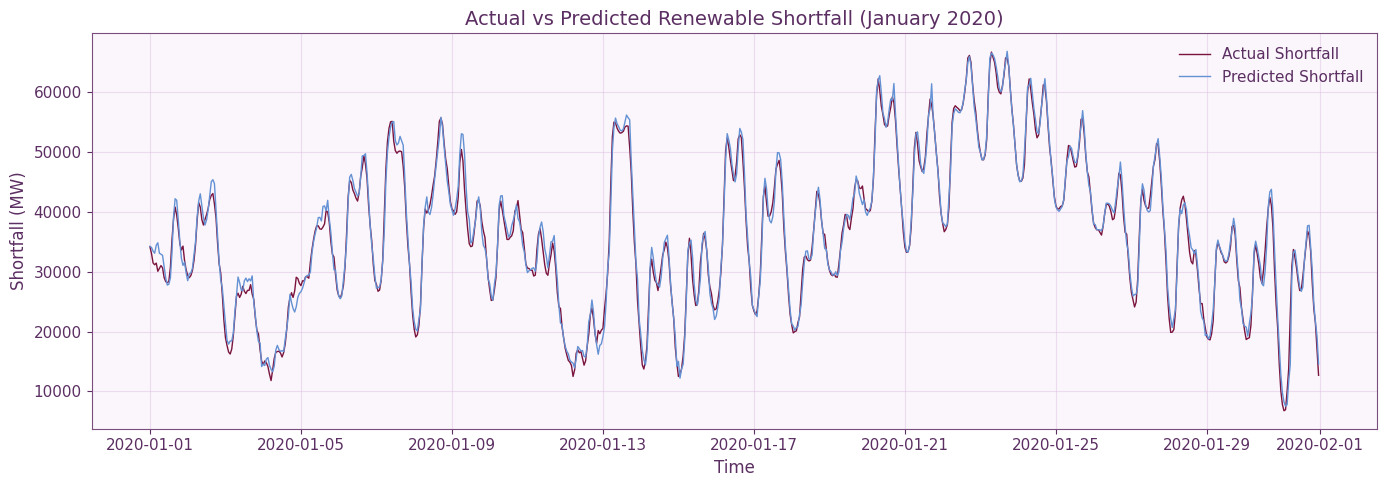

In [72]:
results_rf = test[["utc_timestamp", "shortfall_mw"]].copy()
results_rf["predicted_shortfall_mw"] = y_pred_rf

# Example: first month of test period
plot_rf = results_rf[
    (results_rf["utc_timestamp"] >= "2020-01-01") &
    (results_rf["utc_timestamp"] < "2020-02-01")
]

plt.figure(figsize=(14,5))
plt.plot(plot_rf["utc_timestamp"], plot_rf["shortfall_mw"], label="Actual Shortfall", color="#7a133e", linewidth=1)
plt.plot(plot_rf["utc_timestamp"], plot_rf["predicted_shortfall_mw"], label="Predicted Shortfall", color="#6491D4", linewidth=1)
plt.title("Actual vs Predicted Renewable Shortfall (January 2020)")
plt.xlabel("Time")
plt.ylabel("Shortfall (MW)")
plt.legend()
plt.tight_layout()
plt.show()

The comparison between actual and predicted renewable shortfall demonstrates that the Random Forest model performs exceptionally well. The model accurately captures both the overall trend and short-term fluctuations in the shortfall series, with minimal deviation between predicted and observed values. This confirms the high predictive accuracy indicated by the performance metrics and suggests that the model is well-suited for forecasting renewable energy shortfalls.
The strong agreement between predicted and actual values suggests that the combination of weather variables, temporal features, and lagged shortfall variables provides sufficient information to accurately model renewable energy shortfall dynamics.

### Feature Importance Analysis

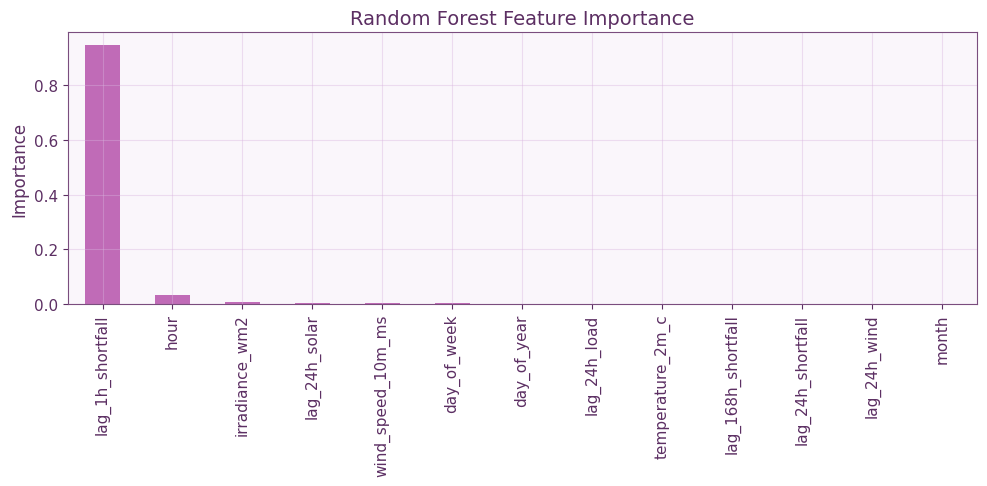

lag_1h_shortfall      0.947139
hour                  0.032266
irradiance_wm2        0.006785
lag_24h_solar         0.004281
wind_speed_10m_ms     0.002589
day_of_week           0.002272
day_of_year           0.001014
lag_24h_load          0.000978
temperature_2m_c      0.000953
lag_168h_shortfall    0.000633
lag_24h_shortfall     0.000492
lag_24h_wind          0.000441
month                 0.000159
dtype: float64

In [73]:
feature_importance_rf = pd.Series(rf.feature_importances_, index=feature_cols)
feature_importance_rf = feature_importance_rf.sort_values(ascending=False)

plt.figure(figsize=(10,5))
feature_importance_rf.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

feature_importance_rf

The feature importance results reveal that the Random Forest model is dominated by the one-hour lagged shortfall variable, which contributes approximately 94.7% of the total importance. This indicates that renewable shortfall is highly persistent on short time scales, and that the most recent shortfall value is by far the strongest predictor of the next hour’s shortfall. The hour of day is the second most important feature, reflecting daily cyclical behavior in electricity demand and renewable generation. Weather variables such as irradiance, wind speed, and temperature contribute smaller but still meaningful amounts of information. Overall, these results suggest that short-term renewable shortfall forecasting is driven mainly by temporal persistence, with weather and seasonal structure providing secondary predictive value.
One limitation of this model is that the dominance of the one-hour lagged shortfall reduces the interpretability of the remaining predictors. To better evaluate the independent role of weather variables, an additional model could be trained without the lagged shortfall features.

## Part 5: RF Model without 1hr shortfall lag

In [74]:
feature_cols_no_1h = [
    "irradiance_wm2",
    "wind_speed_10m_ms",
    "temperature_2m_c",
    "hour",
    "day_of_week",
    "month",
    "day_of_year",
    "lag_24h_shortfall",
    "lag_168h_shortfall",
    "lag_24h_load",
    "lag_24h_wind",
    "lag_24h_solar"
]

target_col = "shortfall_mw"

X_train_no_1h = train[feature_cols_no_1h]
y_train = train[target_col]

X_test_no_1h = test[feature_cols_no_1h]
y_test = test[target_col]

print("X_train shape:", X_train_no_1h.shape)
print("X_test shape:", X_test_no_1h.shape)

X_train shape: (43551, 12)
X_test shape: (6576, 12)


In [75]:
rf_no_1h = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

rf_no_1h.fit(X_train_no_1h, y_train)

y_pred_rf_no_1h = rf_no_1h.predict(X_test_no_1h)

print("Random Forest model without lag_1h_shortfall trained successfully.")

Random Forest model without lag_1h_shortfall trained successfully.


In [76]:
mae_rf_no_1h = mean_absolute_error(y_test, y_pred_rf_no_1h)
rmse_rf_no_1h = np.sqrt(mean_squared_error(y_test, y_pred_rf_no_1h))
r2_rf_no_1h = r2_score(y_test, y_pred_rf_no_1h)

print("Random Forest Performance")
print(f"MAE:  {mae_rf_no_1h:,.2f} MW")
print(f"RMSE: {rmse_rf_no_1h:,.2f} MW")
print(f"R²:   {r2_rf_no_1h:.4f}")

Random Forest Performance
MAE:  5,173.30 MW
RMSE: 6,598.63 MW
R²:   0.6971


The reduced Random Forest model, trained without the one-hour lagged shortfall variable, achieved an MAE of 5,173 MW, an RMSE of 6,599 MW, and an R² of 0.6971. Although this performance is weaker than that of the full model, it still indicates substantial predictive capability. The large drop in accuracy confirms that renewable shortfall exhibits strong short-term persistence, meaning that the previous hour’s shortfall is highly informative for near-future forecasting. At the same time, the reduced model demonstrates that weather variables and cyclical temporal features still explain a significant portion of the observed variability.

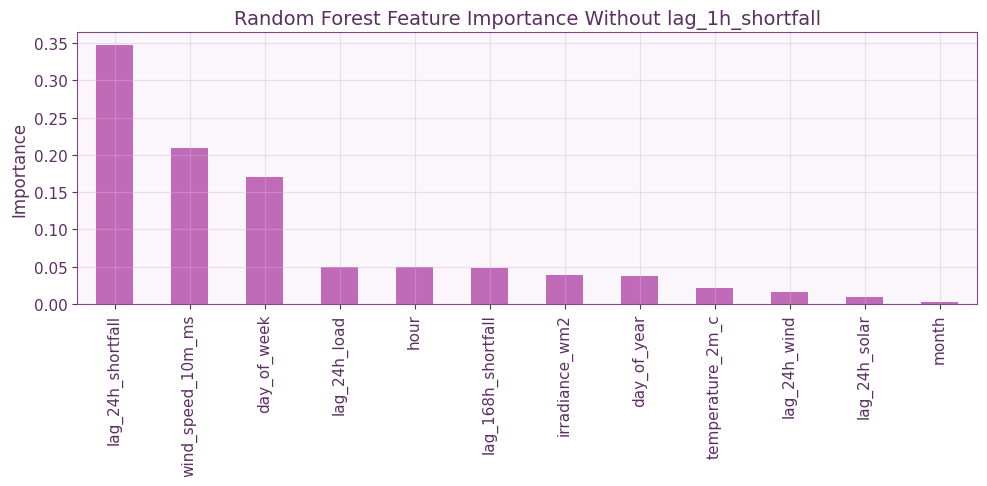

lag_24h_shortfall     0.347245
wind_speed_10m_ms     0.209466
day_of_week           0.170611
lag_24h_load          0.049974
hour                  0.049536
lag_168h_shortfall    0.048345
irradiance_wm2        0.038404
day_of_year           0.036899
temperature_2m_c      0.021618
lag_24h_wind          0.016315
lag_24h_solar         0.009441
month                 0.002146
dtype: float64

In [77]:
feature_importance_rf_no_1h = pd.Series(rf_no_1h.feature_importances_, index=feature_cols_no_1h)
feature_importance_rf_no_1h = feature_importance_rf_no_1h.sort_values(ascending=False)

plt.figure(figsize=(10,5))
feature_importance_rf_no_1h.plot(kind="bar")
plt.title("Random Forest Feature Importance Without lag_1h_shortfall")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

feature_importance_rf_no_1h

When the one-hour lagged shortfall is removed, the model relies more heavily on daily patterns, weather conditions, and demand-related variables. This reveals that renewable shortfall is influenced not only by short-term persistence but also by predictable cyclical behavior and meteorological factors.